In [2]:
# Importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn import metrics
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings("ignore")
from transformers.utils import logging
logging.set_verbosity_error()
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

In [4]:
#Loading data into dataframe

data = pd.read_csv("/kaggle/input/datasets-for-suhi/combined_v2.csv")
data.head()

,soil_moisture,NDBI,BU,Roughness,Slope,NDVI,LST,UHI,UTFVI,NDWI,...,CH4,CO,HCHO,NO2,O3,SO2,Longitude,Latitude,Zone,geometry
0,125.331552,-0.129746,-0.271251,0.0,89.999694,0.545336,28.333197,-2.657156,-0.199289,-0.567614,...,1907.877197,0.033998,0.00011,0.000133,0.142454,0.000028,9.240700,45.419989,4,POINT (9.240699833152282 45.41998857495235)
1,130.649125,-0.091416,-0.238252,0.0,89.999691,0.705981,27.473296,-3.061812,-0.236826,-0.602588,...,1907.877197,0.033998,0.00011,0.000133,0.142454,0.000028,9.240341,45.420168,4,POINT (9.240340507038631 45.420168238009175)
2,130.643567,-0.112200,-0.245295,0.0,89.999691,0.705981,27.473296,-3.061812,-0.236826,-0.579211,...,1907.877197,0.033998,0.00011,0.000133,0.142454,0.000028,9.240520,45.420168,4,POINT (9.240520170095458 45.42016823800918)
3,195.133153,-0.129746,-0.271251,0.0,89.999694,0.545336,28.333197,-2.657156,-0.199289,-0.560563,...,1907.877197,0.033998,0.00011,0.000133,0.142454,0.000028,9.240700,45.420168,4,POINT (9.240699833152282 45.42016823800918)
4,132.716402,-0.129746,-0.271251,0.0,89.999694,0.545336,28.333197,-2.657156,-0.199289,-0.621918,...,1907.877197,0.033998,0.00011,0.000133,0.142454,0.000028,9.240879,45.420168,4,POINT (9.240879496209104 45.42016823800917)


In [5]:
#Listing the features of the dataset

data.columns

Index(['soil_moisture', 'NDBI', 'BU', 'Roughness', 'Slope', 'NDVI', 'LST',
       'UHI', 'UTFVI', 'NDWI', 'SAVI', 'lulc_classes', 'Amenity', 'LandUse',
       'GHI', 'CH4', 'CO', 'HCHO', 'NO2', 'O3', 'SO2', 'Longitude', 'Latitude',
       'Zone', 'geometry'],
      dtype='object')

In [6]:
# Overview of the dataset
print("Shape of the dataset:", data.shape)
print("\nFirst few rows of the dataset:")
print(data.head())

# Summary statistics
print("\nSummary statistics of the dataset:")
print(data.describe())

# Check for missing values
print("\nMissing values in the dataset:")
print(data.isnull().sum())

# Check data types
print("\nData types of each column:")
print(data.dtypes)

Shape of the dataset: (1973361, 25)

First few rows of the dataset:
   soil_moisture      NDBI        BU  Roughness      Slope      NDVI  \
0     125.331552 -0.129746 -0.271251        0.0  89.999694  0.545336   
1     130.649125 -0.091416 -0.238252        0.0  89.999691  0.705981   
2     130.643567 -0.112200 -0.245295        0.0  89.999691  0.705981   
3     195.133153 -0.129746 -0.271251        0.0  89.999694  0.545336   
4     132.716402 -0.129746 -0.271251        0.0  89.999694  0.545336   

         LST       UHI     UTFVI      NDWI  ...          CH4        CO  \
0  28.333197 -2.657156 -0.199289 -0.567614  ...  1907.877197  0.033998   
1  27.473296 -3.061812 -0.236826 -0.602588  ...  1907.877197  0.033998   
2  27.473296 -3.061812 -0.236826 -0.579211  ...  1907.877197  0.033998   
3  28.333197 -2.657156 -0.199289 -0.560563  ...  1907.877197  0.033998   
4  28.333197 -2.657156 -0.199289 -0.621918  ...  1907.877197  0.033998   

      HCHO       NO2        O3       SO2  Longitude   

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define features and target
features = ['soil_moisture', 'NDBI', 'NDVI', 'NDWI', 'SAVI', 'Longitude', 'Latitude']
X = data[features]
y = data['LST']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

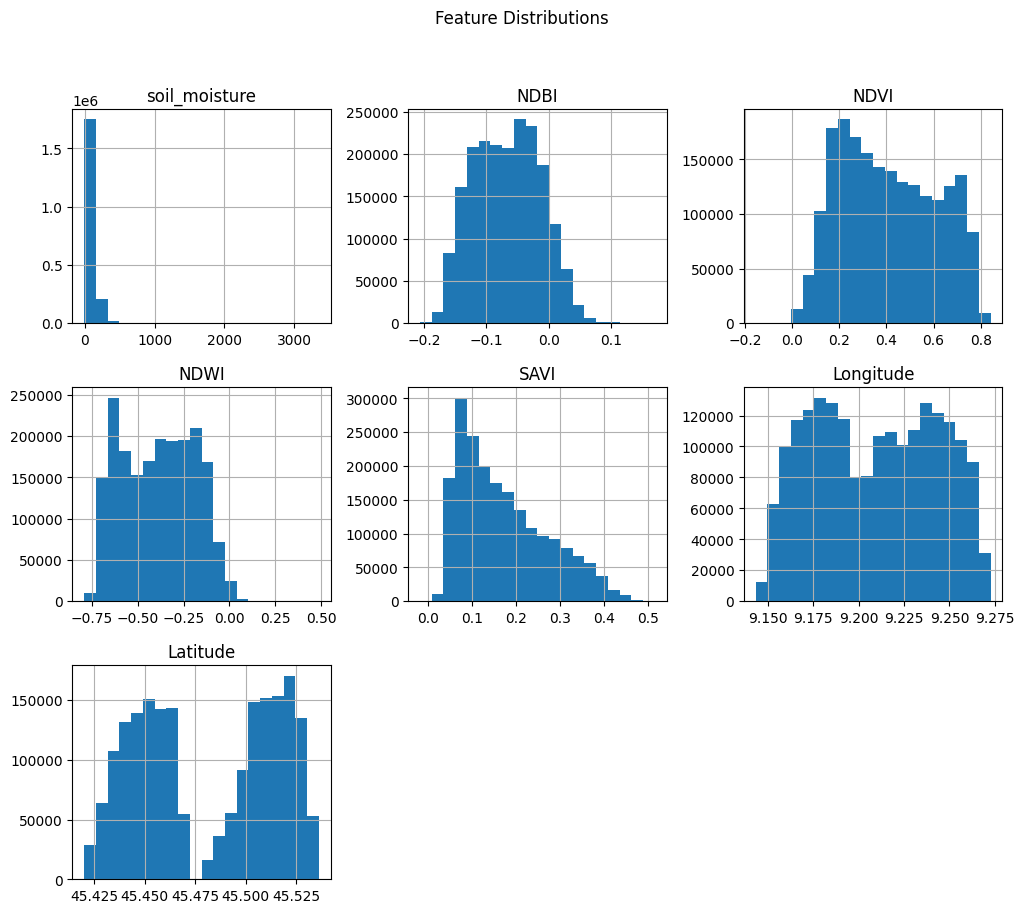

In [9]:
# Histogram for each feature
data[features].hist(figsize=(12, 10), bins=20)
plt.suptitle('Feature Distributions')
plt.show()

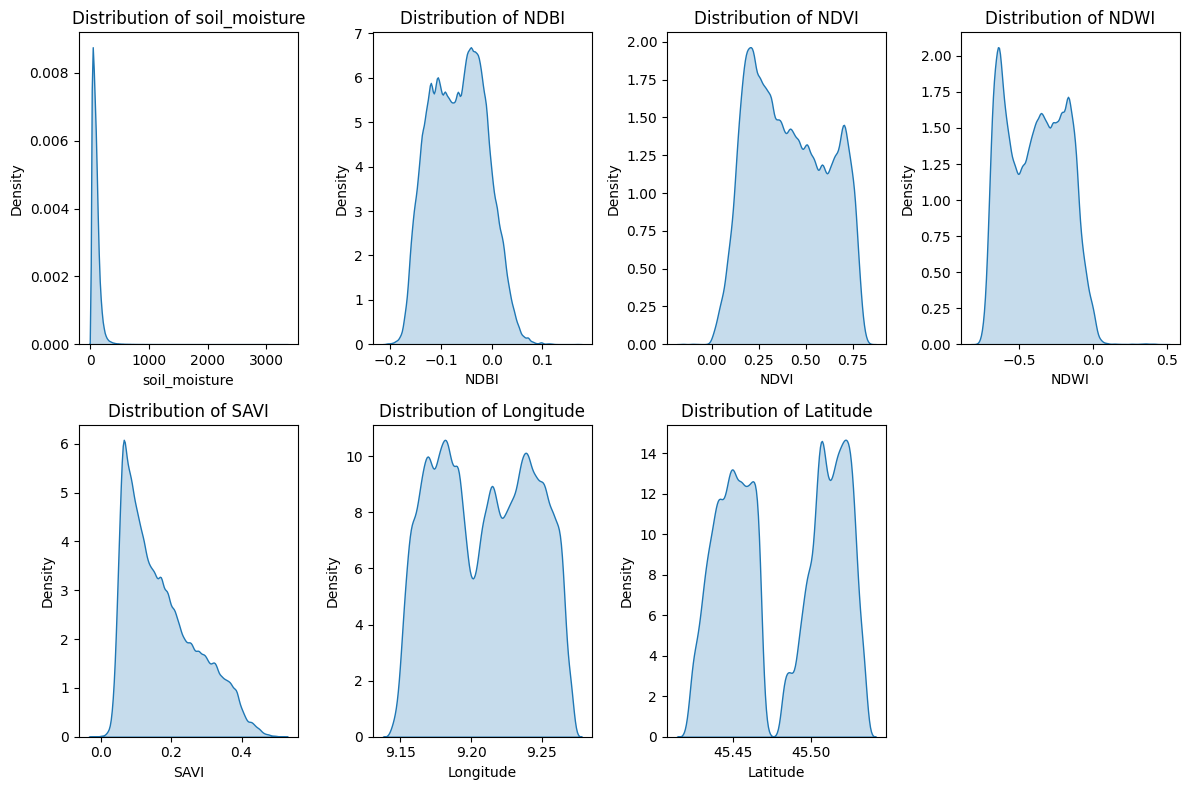

In [10]:

# KDE plot for each feature
plt.figure(figsize=(12, 8))
for i, feature in enumerate(features):
    plt.subplot(2, 4, i + 1)
    sns.kdeplot(data[feature], shade=True)
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

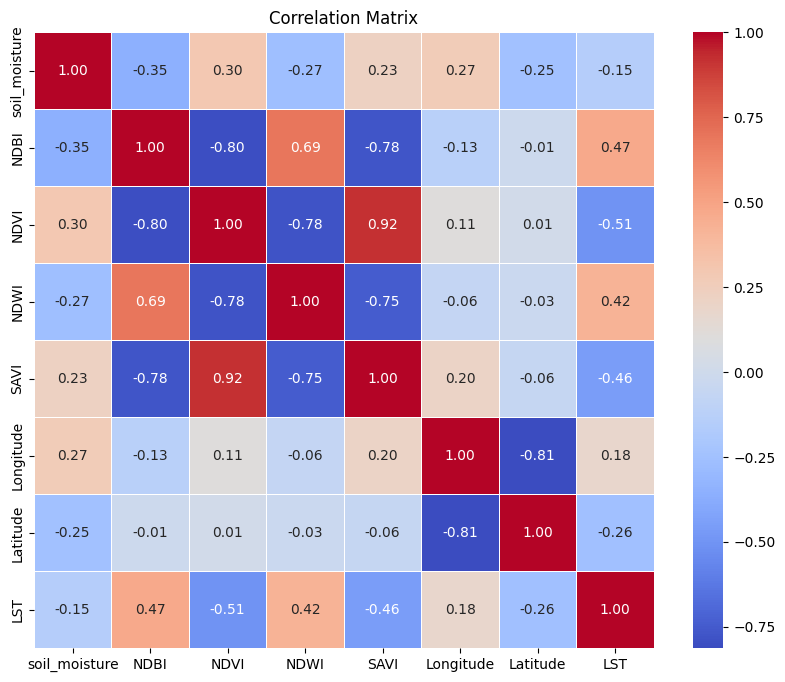

In [11]:
# Correlation heatmap to identify relationships between features
plt.figure(figsize=(10, 8))
correlation_matrix = data[features + ['LST']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

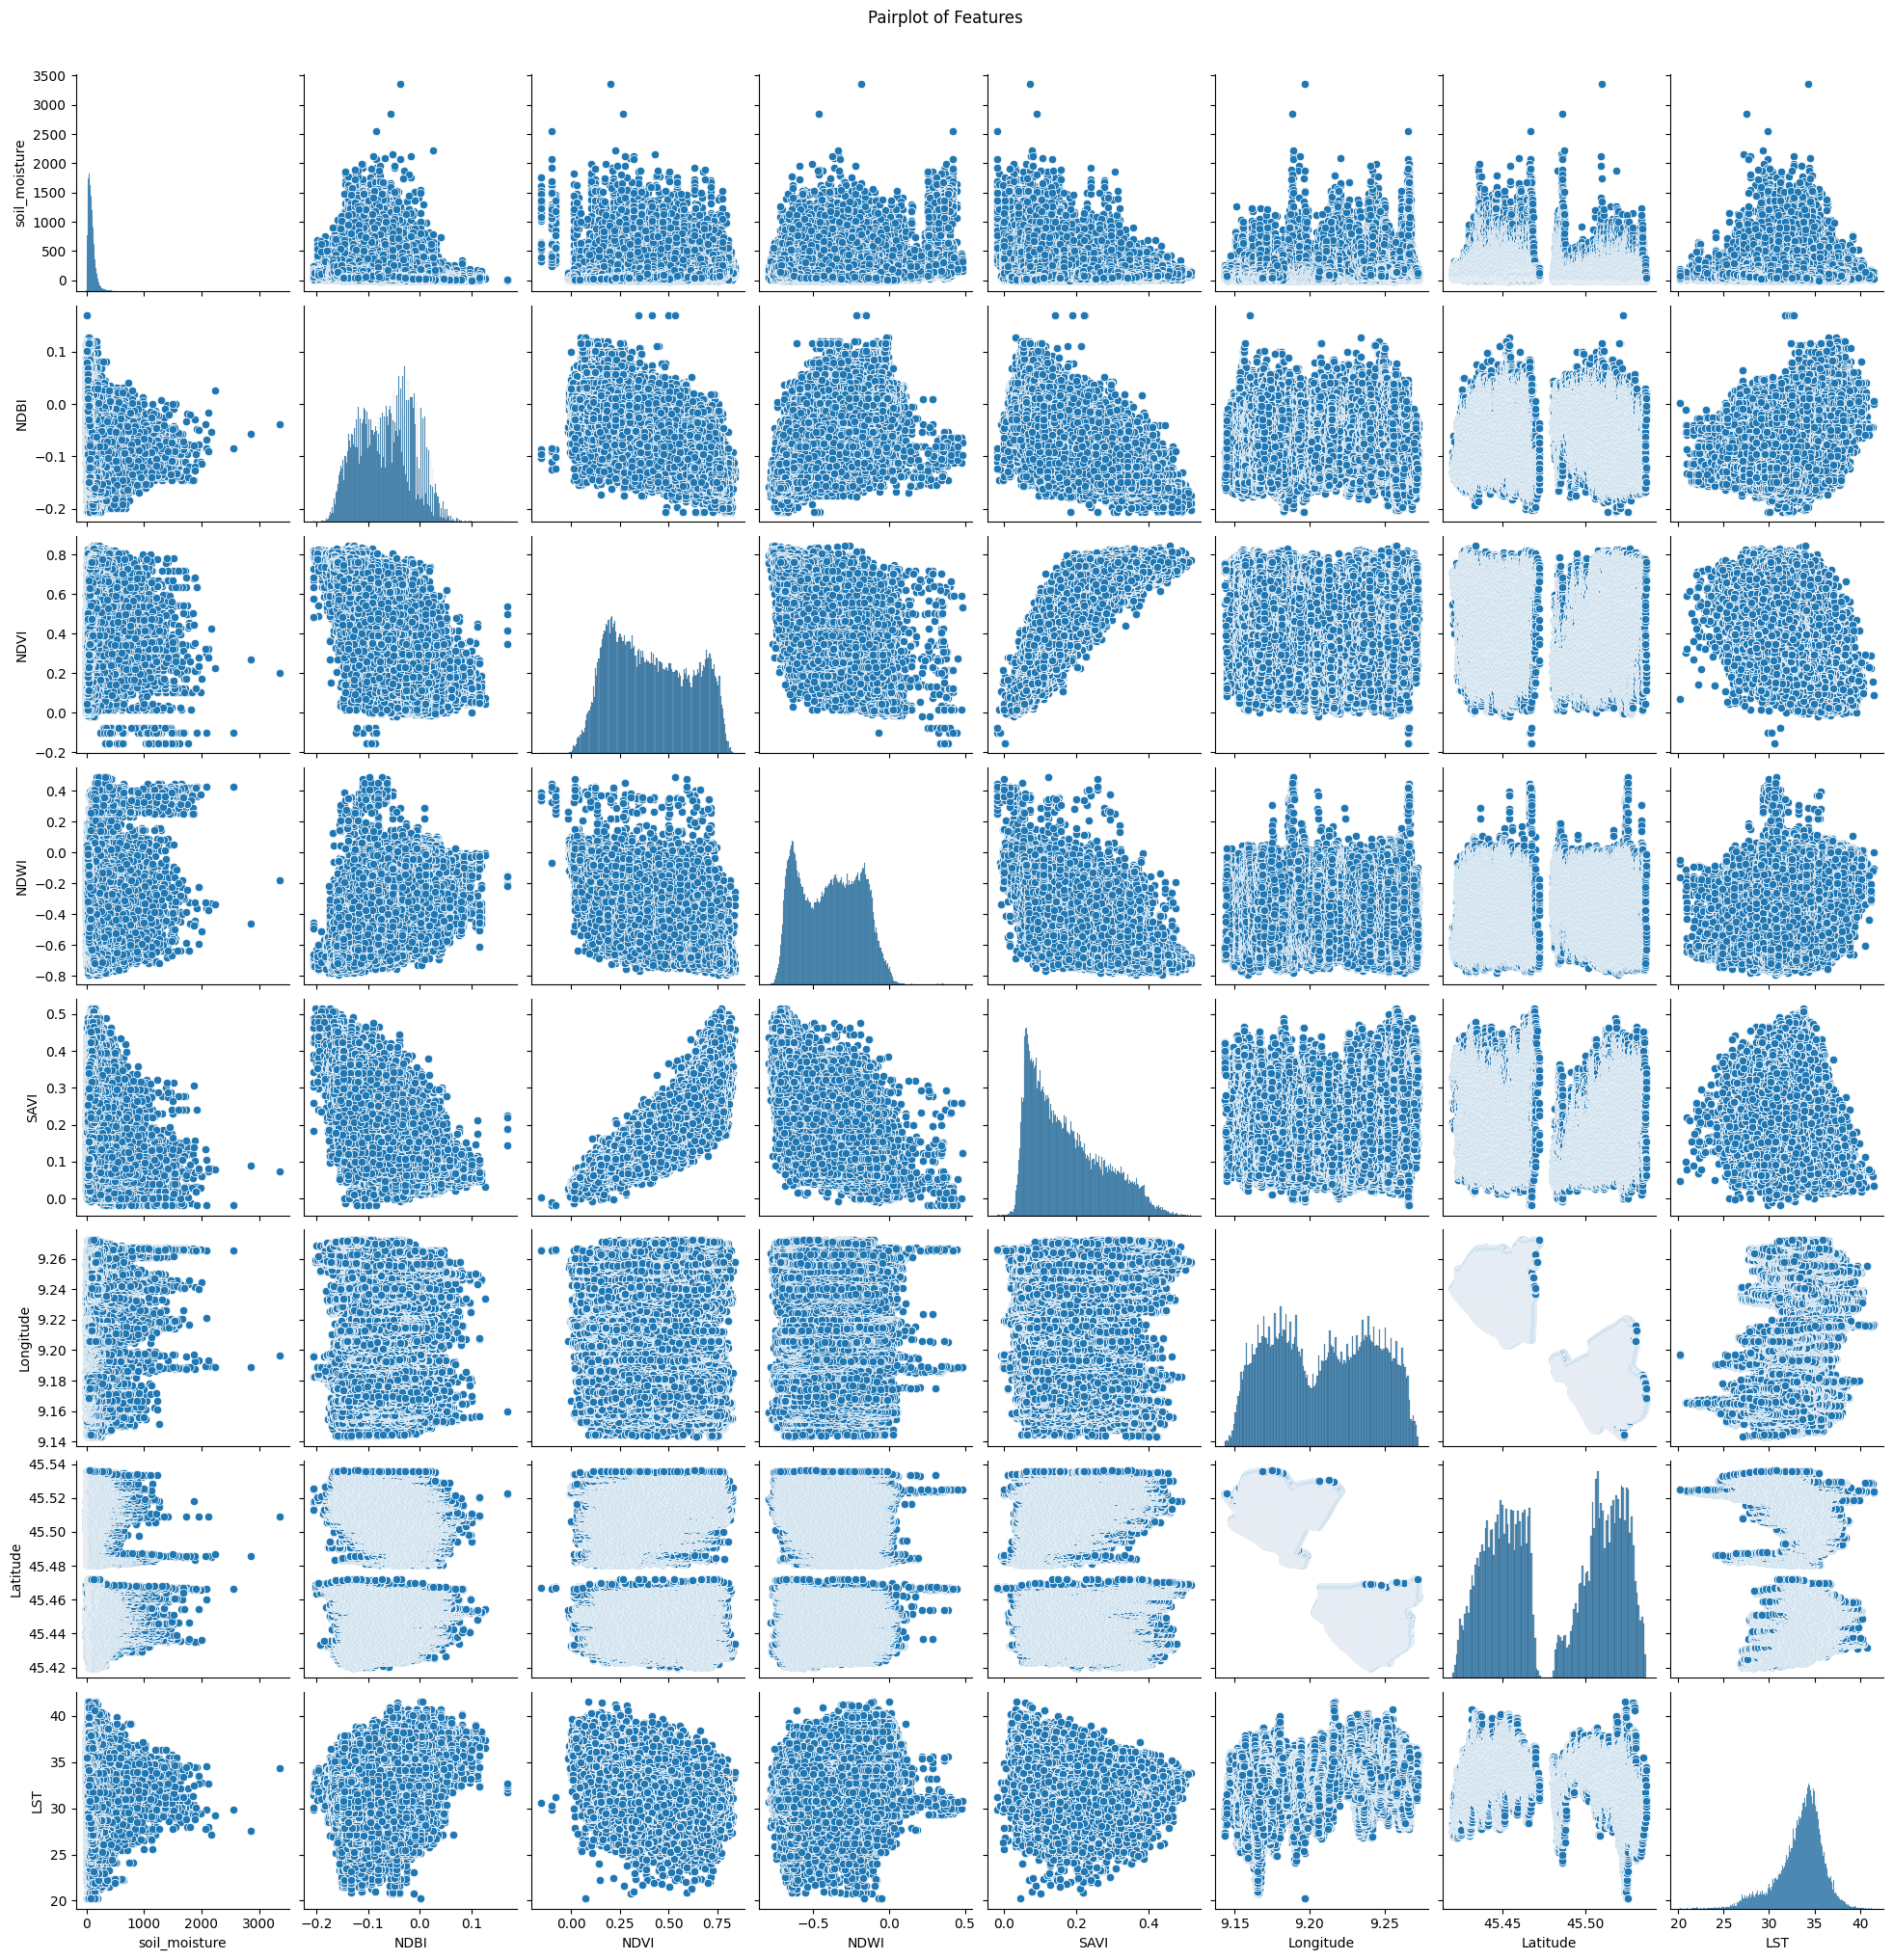

In [12]:
# Pairplot to see pairwise relationships
sns.pairplot(data[features + ['LST']])
plt.suptitle('Pairplot of Features', y=1.02)
plt.show()

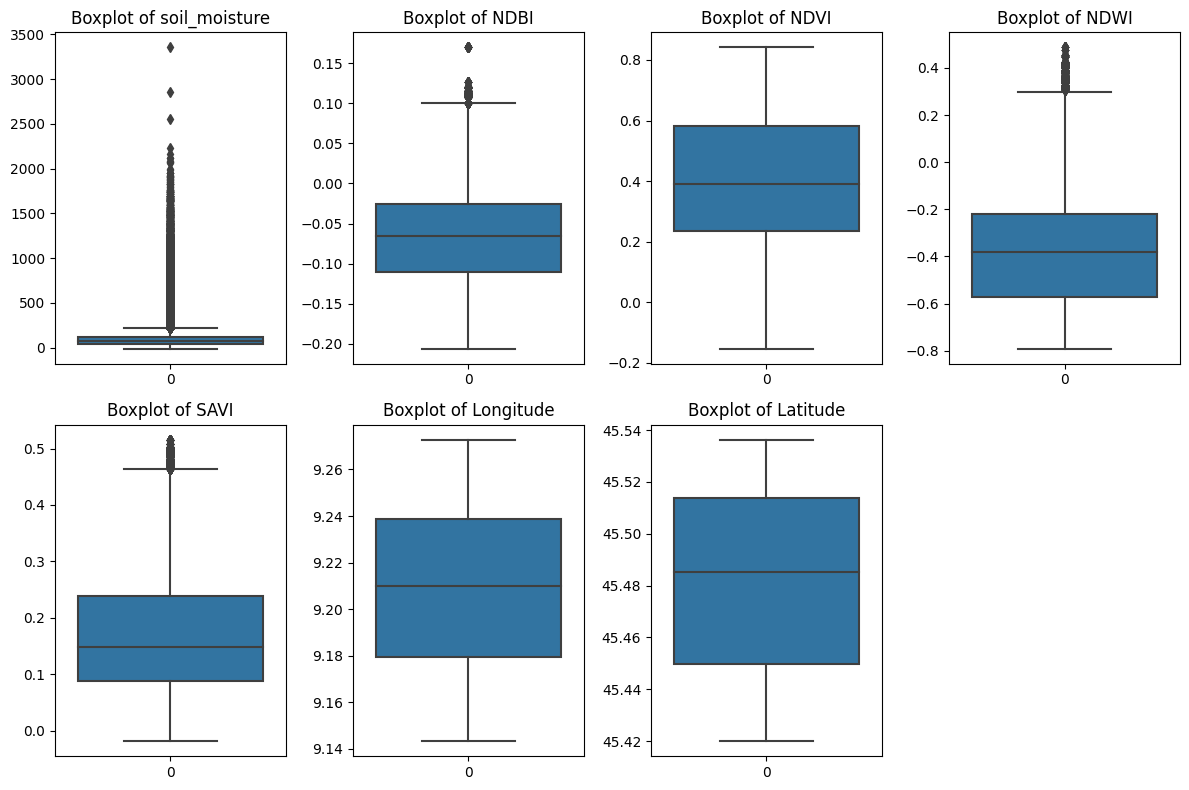

In [13]:
# Boxplot for each feature to detect outliers
plt.figure(figsize=(12, 8))
for i, feature in enumerate(features):
    plt.subplot(2, 4, i + 1)
    sns.boxplot(data[feature])
    plt.title(f'Boxplot of {feature}')
plt.tight_layout()
plt.show()

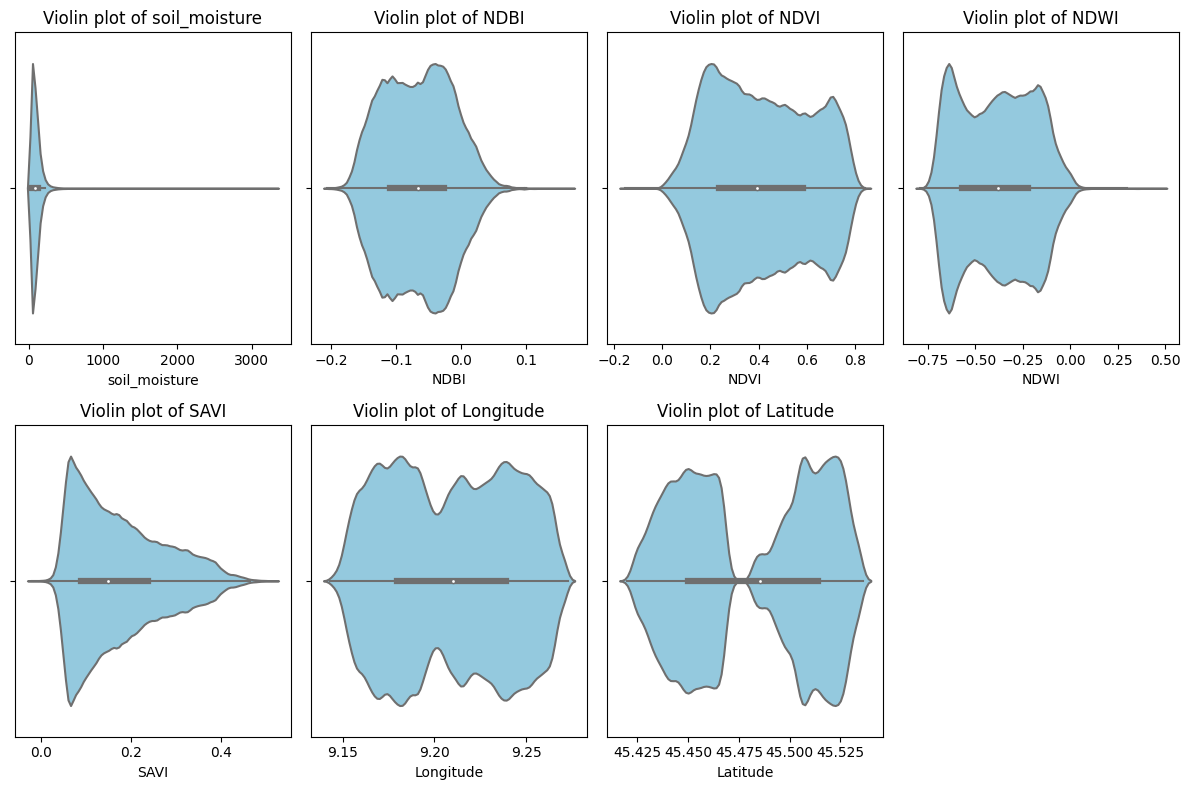

In [14]:
# Violin plot for each feature with respect to the target variable (LST)
plt.figure(figsize=(12, 8))
for i, feature in enumerate(features):
    plt.subplot(2, 4, i + 1)
    sns.violinplot(x=data[feature], color='skyblue')
    plt.title(f'Violin plot of {feature}')
plt.tight_layout()
plt.show()

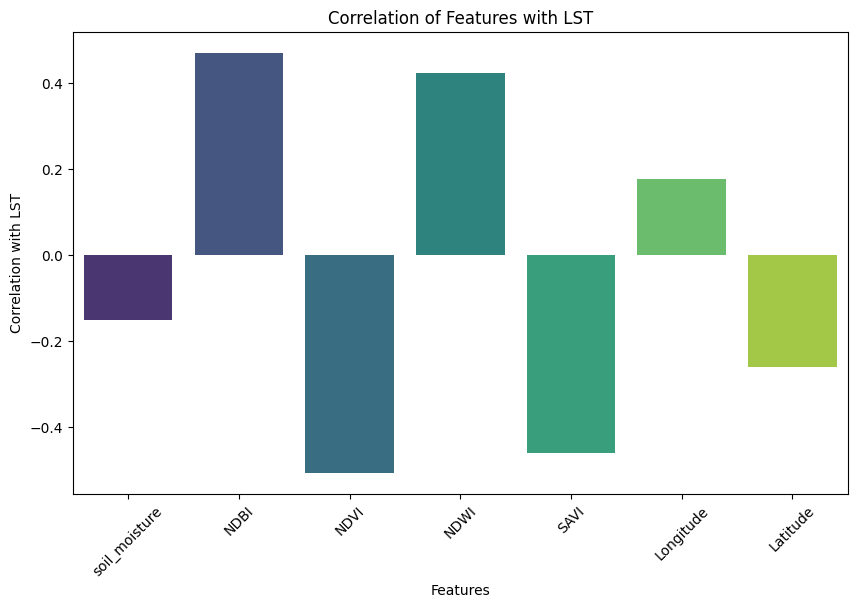

In [15]:
# Correlation of each feature with the target (LST)
corr_with_target = data[features + ['LST']].corr()['LST'].drop('LST')
plt.figure(figsize=(10, 6))
sns.barplot(x=corr_with_target.index, y=corr_with_target.values, palette='viridis')
plt.title('Correlation of Features with LST')
plt.xlabel('Features')
plt.ylabel('Correlation with LST')
plt.xticks(rotation=45)
plt.show()

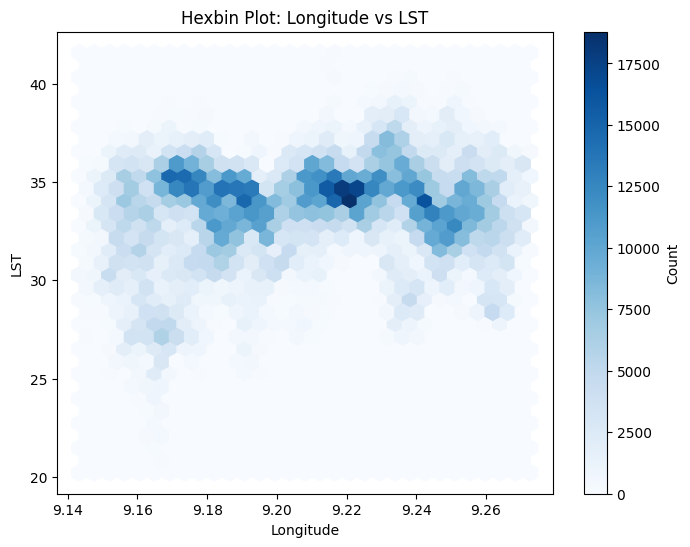

In [16]:
# Hexbin plot between a feature and the target variable
plt.figure(figsize=(8, 6))
plt.hexbin(data['Longitude'], data['LST'], gridsize=30, cmap='Blues')
plt.colorbar(label='Count')
plt.title('Hexbin Plot: Longitude vs LST')
plt.xlabel('Longitude')
plt.ylabel('LST')
plt.show()

In [17]:
# Initialize and train model
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f} °C")
print(f"RMSE: {rmse:.2f} °C")
print(f"R² Score: {r2:.2f}")

MAE: 0.00 °C
RMSE: 0.07 °C
R² Score: 1.00


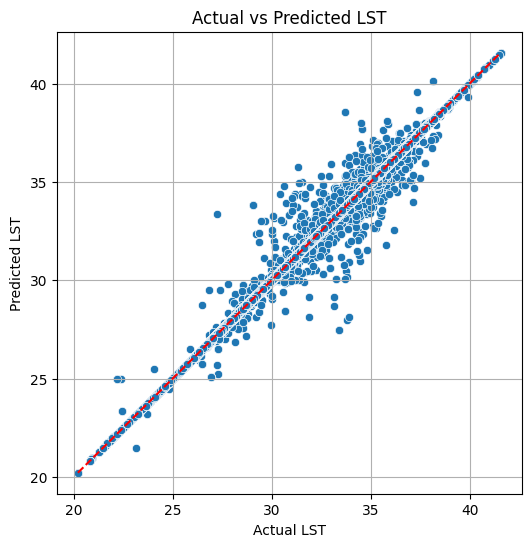

In [18]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual LST")
plt.ylabel("Predicted LST")
plt.title("Actual vs Predicted LST")
plt.grid(True)
plt.show()

In [19]:
import pickle

# Save the trained decision tree model to a file
with open("decision_tree_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully as 'decision_tree_model.pkl'")

Model saved successfully as 'decision_tree_model.pkl'


In [20]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pickle

# Scaling features (important for KNN)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize KNN model with distance-based weighting
knn_model = KNeighborsRegressor(n_neighbors=5, weights='distance')

# Train the model
knn_model.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_knn = knn_model.predict(X_test_scaled)

# Evaluate performance
mae_knn = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)

print(f"KNN Regressor Results:")
print(f"MAE: {mae_knn:.2f} °C")
print(f"RMSE: {rmse_knn:.2f} °C")
print(f"R² Score: {r2_knn:.2f}")

KNN Regressor Results:
MAE: 0.04 °C
RMSE: 0.23 °C
R² Score: 0.99


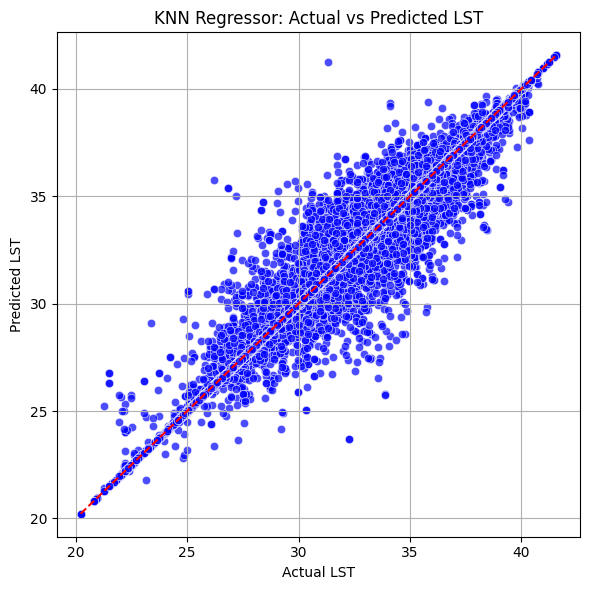

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot actual vs predicted values
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred_knn, color='blue', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Perfect prediction line
plt.xlabel("Actual LST")
plt.ylabel("Predicted LST")
plt.title("KNN Regressor: Actual vs Predicted LST")
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
# Save the trained KNN model to a file
with open("knn_model.pkl", "wb") as file:
    pickle.dump(knn_model, file)

print("KNN model saved successfully as 'knn_model.pkl'")

KNN model saved successfully as 'knn_model.pkl'


In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pickle
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Scaling features (important for models like LR)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize Linear Regression model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluation
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression Results:")
print(f"MAE: {mae_lr:.2f} °C")
print(f"RMSE: {rmse_lr:.2f} °C")
print(f"R² Score: {r2_lr:.2f}")

Linear Regression Results:
MAE: 1.46 °C
RMSE: 1.99 °C
R² Score: 0.34


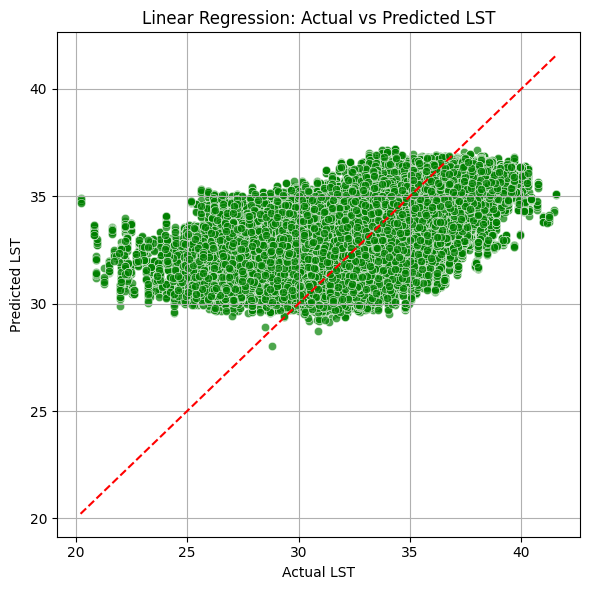

In [24]:
# Plot actual vs predicted values
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred_lr, color='green', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Perfect prediction line
plt.xlabel("Actual LST")
plt.ylabel("Predicted LST")
plt.title("Linear Regression: Actual vs Predicted LST")
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
# Save the trained Linear Regression model to a file
with open("lr_model.pkl", "wb") as file:
    pickle.dump(lr_model, file)

print("Linear Regression model saved successfully as 'lr_model.pkl'")

Linear Regression model saved successfully as 'lr_model.pkl'


In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle

# Scale the features (not mandatory for RF, but okay to standardize across models)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Results:")
print(f"MAE: {mae_rf:.2f} °C")
print(f"RMSE: {rmse_rf:.2f} °C")
print(f"R² Score: {r2_rf:.2f}")

Random Forest Regressor Results:
MAE: 0.01 °C
RMSE: 0.04 °C
R² Score: 1.00


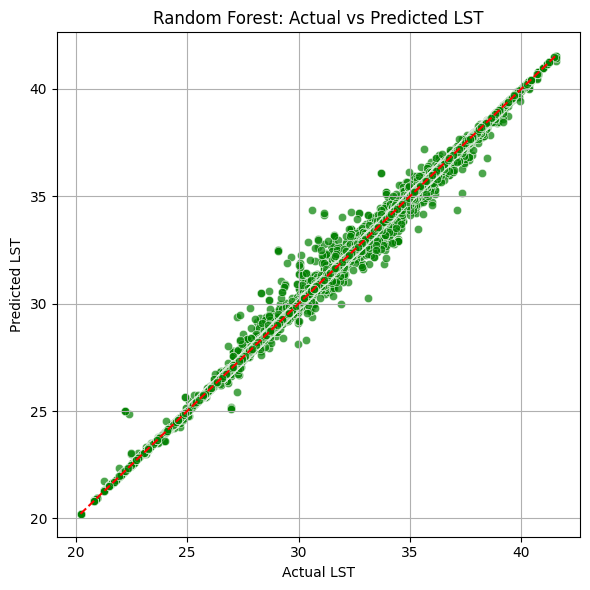

In [27]:
# Plot actual vs predicted
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, color='green', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual LST")
plt.ylabel("Predicted LST")
plt.title("Random Forest: Actual vs Predicted LST")
plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:

# Save model and scaler
with open("random_forest_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

with open("rf_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Random Forest model and scaler saved successfully.")

Random Forest model and scaler saved successfully.


In [29]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Scale the input features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the MLP model
mlp_model = Sequential([
    Dense(64, input_shape=(X_train_scaled.shape[1],), activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)  # Output layer for regression
])

mlp_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model
history = mlp_model.fit(
    X_train_scaled, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    verbose=1
)

# Predict
y_pred_mlp = mlp_model.predict(X_test_scaled).flatten()

# Evaluation
mae = mean_absolute_error(y_test, y_pred_mlp)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
r2 = r2_score(y_test, y_pred_mlp)

print("MLP Regressor Results:")
print(f"MAE: {mae:.2f} °C")
print(f"RMSE: {rmse:.2f} °C")
print(f"R² Score: {r2:.2f}")

2025-05-02 15:44:18.357229: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/100
44401/44401 ━━━━━━━━━━━━━━━━━━━━ 69s 2ms/step - loss: 21.3037 - mae: 2.3719 - val_loss: 2.3218 - val_mae: 1.1122
Epoch 2/100
44401/44401 ━━━━━━━━━━━━━━━━━━━━ 64s 1ms/step - loss: 2.3784 - mae: 1.1388 - val_loss: 2.1005 - val_mae: 1.0644
Epoch 3/100
44401/44401 ━━━━━━━━━━━━━━━━━━━━ 64s 1ms/step - loss: 2.2157 - mae: 1.1095 - val_loss: 1.9334 - val_mae: 1.0426
Epoch 4/100
44401/44401 ━━━━━━━━━━━━━━━━━━━━ 64s 1ms/step - loss: 2.0848 - mae: 1.0853 - val_loss: 1.8189 - val_mae: 1.0138
Epoch 5/100
44401/44401 ━━━━━━━━━━━━━━━━━━━━ 64s 1ms/step - loss: 1.9973 - mae: 1.0653 - val_loss: 1.7971 - val_mae: 1.0171
Epoch 6/100
44401/44401 ━━━━━━━━━━━━━━━━━━━━ 64s 1ms/step - loss: 1.9380 - mae: 1.0507 - val_loss: 1.7177 - val_mae: 0.9917
Epoch 7/100
44401/44401 ━━━━━━━━━━━━━━━━━━━━ 64s 1ms/step - loss: 1.9050 - mae: 1.0432 - val_loss: 1.7555 - val_mae: 1.0050
Epoch 8/100
44401/44401 ━━━━━━━━━━━━━━━━━━━━ 64s 1ms/step - loss: 1.8836 - mae: 1.0380 - val_loss: 1.7135 - val_mae: 0.9880
Epoch 9

KeyboardInterrupt: 

In [ ]:
# Plot predictions
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred_mlp, color='purple', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual LST")
plt.ylabel("Predicted LST")
plt.title("MLP Regressor: Actual vs Predicted LST")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Save the model and scaler
mlp_model.save("mlp_model.keras")
with open("mlp_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("MLP model and scaler saved successfully.")

In [ ]:
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle

# ⚠️ Limit to a subset of the data (e.g., 10,000 samples for faster training)
sample_limit = 150000
X_sample = X_train[:sample_limit]
y_sample = y_train[:sample_limit]

# Scale features
scaler = MinMaxScaler()
X_sample_scaled = scaler.fit_transform(X_sample)
X_test_scaled = scaler.transform(X_test)

# Initialize and train SVR model
svm_model = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
svm_model.fit(X_sample_scaled, y_sample)

# Predict on test data
y_pred_svr = svm_model.predict(X_test_scaled)

# Evaluate
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)

print("SVR Results:")
print(f"MAE: {mae_svr:.2f} °C")
print(f"RMSE: {rmse_svr:.2f} °C")
print(f"R² Score: {r2_svr:.2f}")

In [ ]:

# Plot actual vs predicted
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred_svr, color='teal', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual LST")
plt.ylabel("Predicted LST")
plt.title("SVR: Actual vs Predicted LST")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Save model and scaler
with open("svr_model_limited.pkl", "wb") as f:
    pickle.dump(svm_model, f)

with open("svr_scaler_limited.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("SVR model and scaler (trained on subset) saved successfully.")

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create the results table from your provided values
results_df = pd.DataFrame({
    "Model": [
        "Decision Tree", "KNN", "Linear Regression", 
        "Random Forest", "MLP", "SVR"
    ],
    "MAE (°C)": [0.00, 0.04, 1.46, 0.01, 0.92, 1.08],
    "RMSE (°C)": [0.07, 0.23, 1.99, 0.04, 1.21, 1.52],
    "R² Score": [1.00, 0.99, 0.34, 1.00, 0.75, 0.61]
})

# Display table
print("📊 Model Performance Summary:")
display(results_df)

📊 Model Performance Summary:


,Model,MAE (°C),RMSE (°C),R² Score
0,Decision Tree,0.00,0.07,1.00
1,KNN,0.04,0.23,0.99
2,Linear Regression,1.46,1.99,0.34
3,Random Forest,0.01,0.04,1.00
4,MLP,0.92,1.21,0.75
5,SVR,1.08,1.52,0.61


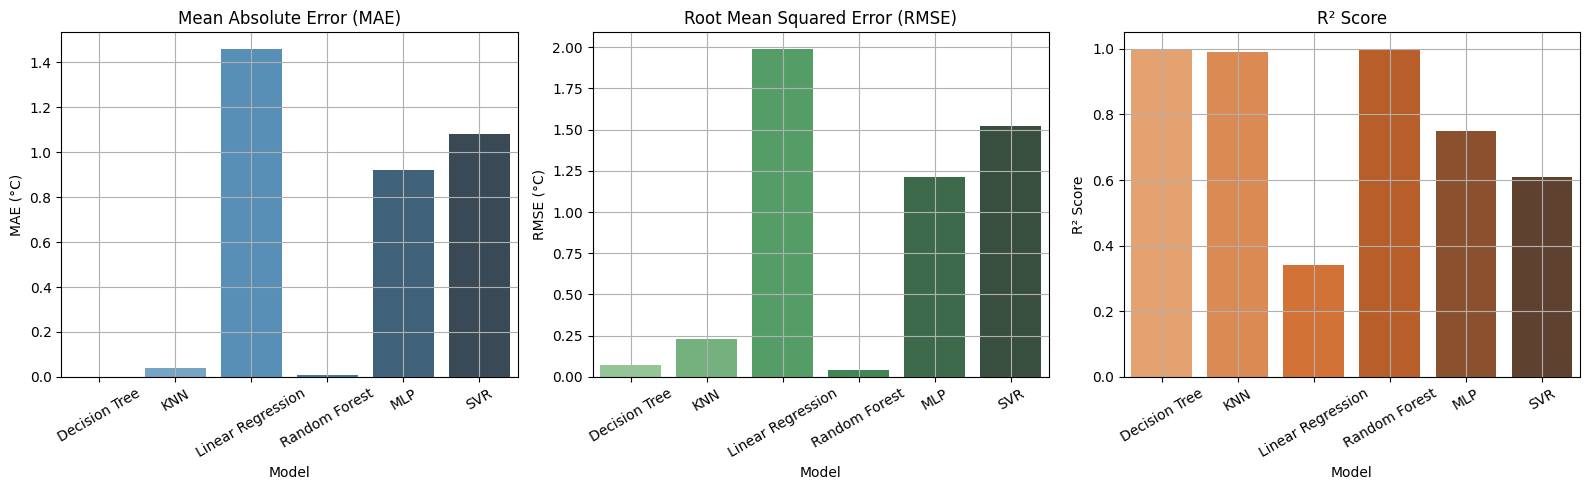

In [32]:
# Plot comparison bar charts
plt.figure(figsize=(16, 5))

# MAE
plt.subplot(1, 3, 1)
sns.barplot(x="Model", y="MAE (°C)", data=results_df, palette="Blues_d")
plt.title("Mean Absolute Error (MAE)")
plt.xticks(rotation=30)
plt.grid(True)

# RMSE
plt.subplot(1, 3, 2)
sns.barplot(x="Model", y="RMSE (°C)", data=results_df, palette="Greens_d")
plt.title("Root Mean Squared Error (RMSE)")
plt.xticks(rotation=30)
plt.grid(True)

# R² Score
plt.subplot(1, 3, 3)
sns.barplot(x="Model", y="R² Score", data=results_df, palette="Oranges_d")
plt.title("R² Score")
plt.xticks(rotation=30)
plt.ylim(0, 1.05)
plt.grid(True)

plt.tight_layout()
plt.show()

In [33]:
import pandas as pd

# Model performance dictionary
model_results = {
    'Decision Tree': {'MAE': 0.00, 'RMSE': 0.07, 'R2': 1.00},
    'KNN': {'MAE': 0.04, 'RMSE': 0.23, 'R2': 0.99},
    'Linear Regression': {'MAE': 1.46, 'RMSE': 1.99, 'R2': 0.34},
    'Random Forest': {'MAE': 0.01, 'RMSE': 0.04, 'R2': 1.00},
    'MLP': {'MAE': 0.92, 'RMSE': 1.21, 'R2': 0.75},
    'SVR': {'MAE': 1.08, 'RMSE': 1.52, 'R2': 0.61}
}

# Convert to DataFrame
results_df = pd.DataFrame(model_results).T
results_df = results_df.sort_values(by=['R2', 'MAE', 'RMSE'], ascending=[False, True, True])

# Display sorted results
print("Model Performance Ranking:\n")
print(results_df)

# Select best model (top of the table)
best_model_name = results_df.index[0]
best_model_metrics = results_df.iloc[0]

print(f"\n✅ Best Model: {best_model_name}")
print(f"MAE: {best_model_metrics['MAE']:.2f} °C")
print(f"RMSE: {best_model_metrics['RMSE']:.2f} °C")
print(f"R² Score: {best_model_metrics['R2']:.2f}")

Model Performance Ranking:

                    MAE  RMSE    R2
Decision Tree      0.00  0.07  1.00
Random Forest      0.01  0.04  1.00
KNN                0.04  0.23  0.99
MLP                0.92  1.21  0.75
SVR                1.08  1.52  0.61
Linear Regression  1.46  1.99  0.34

✅ Best Model: Decision Tree
MAE: 0.00 °C
RMSE: 0.07 °C
R² Score: 1.00


In [34]:
import numpy as np
import joblib
import pickle
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model
import warnings
warnings.filterwarnings("ignore")
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'


# ✅ Load models
dt_model = joblib.load("/kaggle/input/lst-shui/keras/default/1/decision_tree_model.pkl")
rf_model = joblib.load("/kaggle/input/lst-shui/keras/default/1/random_forest_model.pkl")
knn_model = joblib.load("/kaggle/input/lst-shui/keras/default/1/knn_model.pkl")
lr_model = joblib.load("/kaggle/input/lst-shui/keras/default/1/lr_model.pkl")
svr_model = joblib.load("/kaggle/input/lst-shui/keras/default/1/svr_model_limited.pkl")
mlp_model = load_model("/kaggle/input/lst-shui/keras/default/1/mlp_model.keras")

# ✅ Input sample (replace with your own values)
input_values = [12.5, 0.15, 0.45, 0.12, 0.36, 77.5946, 12.9716]
input_array = np.array(input_values).reshape(1, -1)

# ✅ Prediction
# 1. Decision Tree (no scaling needed)
pred_dt = dt_model.predict(input_array)[0]

# 2. Random Forest (scaled)
scaler_rf = MinMaxScaler()
scaler_rf.fit_transform([input_values])
input_scaled_rf = scaler_rf.transform(input_array)
pred_rf = rf_model.predict(input_scaled_rf)[0]

# 3. KNN (scaled)
scaler_knn = MinMaxScaler()
scaler_knn.fit_transform([input_values])
input_scaled_knn = scaler_knn.transform(input_array)
pred_knn = knn_model.predict(input_scaled_knn)[0]

# 4. Linear Regression (scaled)
scaler_lr = MinMaxScaler()
scaler_lr.fit_transform([input_values])
input_scaled_lr = scaler_lr.transform(input_array)
pred_lr = lr_model.predict(input_scaled_lr)[0]

# 5. SVR (scaled)
scaler_svr = MinMaxScaler()
scaler_svr.fit_transform([input_values])
input_scaled_svr = scaler_svr.transform(input_array)
pred_svr = svr_model.predict(input_scaled_svr)[0]

# 6. MLP (scaled)
scaler_mlp = MinMaxScaler()
scaler_mlp.fit_transform([input_values])
input_scaled_mlp = scaler_mlp.transform(input_array)
pred_mlp = mlp_model.predict(input_scaled_mlp).flatten()[0]

# ✅ Print predictions
print(f"🌳 Decision Tree Prediction: {pred_dt:.2f} °C")
print(f"🌲 Random Forest Prediction: {pred_rf:.2f} °C")
print(f"📍 KNN Regressor Prediction: {pred_knn:.2f} °C")
print(f"📈 Linear Regression Prediction: {pred_lr:.2f} °C")
print(f"🌀 SVR Prediction: {pred_svr:.2f} °C")
print(f"🧠 MLP Neural Network Prediction: {pred_mlp:.2f} °C")

I0000 00:00:1746202527.117772     142 service.cc:148] XLA service 0x7f67c4003d40 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746202527.118762     142 service.cc:156]   StreamExecutor device (0): Host, Default Version


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 633ms/step
🌳 Decision Tree Prediction: 30.19 °C
🌲 Random Forest Prediction: 36.24 °C
📍 KNN Regressor Prediction: 34.04 °C
📈 Linear Regression Prediction: 35.16 °C
🌀 SVR Prediction: 22.90 °C
🧠 MLP Neural Network Prediction: 50.27 °C


I0000 00:00:1746202527.635251     142 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [35]:
import numpy as np
import joblib
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings("ignore")


# ✅ Load the Random Forest model
rf_model = joblib.load("/kaggle/input/lst-shui/keras/default/1/random_forest_model.pkl")

# ✅ Input sample (replace with your actual values)
input_values = [12.5, 0.15, 0.45, 0.12, 0.36, 77.5946, 12.9716]
input_array = np.array(input_values).reshape(1, -1)

# ✅ Scale the input (since scaler wasn't saved)
scaler = MinMaxScaler()
scaler.fit_transform([input_values])  # Dummy fit on same values
input_scaled = scaler.transform(input_array)

# ✅ Predict with Random Forest
pred_rf = rf_model.predict(input_scaled)[0]

# ✅ Output
print(f"🌲 Random Forest Prediction: {pred_rf:.2f} °C")

🌲 Random Forest Prediction: 36.24 °C


In [36]:
import numpy as np
import joblib
import warnings
warnings.filterwarnings("ignore")


# ✅ Load the Decision Tree model
dt_model = joblib.load("/kaggle/input/lst-shui/keras/default/1/decision_tree_model.pkl")

# ✅ Input sample (replace with your actual values)
input_values = [12.5, 0.15, 0.45, 0.12, 0.36, 77.5946, 12.9716]
input_array = np.array(input_values).reshape(1, -1)

# ✅ Predict with Decision Tree (no scaling needed)
pred_dt = dt_model.predict(input_array)[0]

# ✅ Output
print(f"🌳 Decision Tree Prediction: {pred_dt:.2f} °C")

🌳 Decision Tree Prediction: 30.19 °C


In [37]:
import numpy as np
import joblib
import warnings
warnings.filterwarnings("ignore")

# ✅ Load the Decision Tree model
dt_model = joblib.load("/kaggle/input/lst-shui/keras/default/1/decision_tree_model.pkl")

# ✅ Take user input
print("Enter the following values:")

soil_moisture = float(input("Soil Moisture: "))
ndbi = float(input("NDBI: "))
ndvi = float(input("NDVI: "))
ndwi = float(input("NDWI: "))
savi = float(input("SAVI: "))
longitude = float(input("Longitude: "))
latitude = float(input("Latitude: "))

# ✅ Create the input array
input_values = [soil_moisture, ndbi, ndvi, ndwi, savi, longitude, latitude]
input_array = np.array(input_values).reshape(1, -1)

# ✅ Predict with Decision Tree (no scaling needed)
pred_dt = dt_model.predict(input_array)[0]

# ✅ Output
print(f"🌳 Decision Tree Prediction: {pred_dt:.2f} °C")

Enter the following values:


Soil Moisture:  12.5
NDBI:  0.15
NDVI:  0.45
NDWI:  0.12
SAVI:  0.36
Longitude:  77.5946
Latitude:  12.9716


🌳 Decision Tree Prediction: 30.19 °C


In [38]:
pip install folium

Note: you may need to restart the kernel to use updated packages.


In [41]:
import numpy as np
import pandas as pd
import joblib
import warnings
warnings.filterwarnings("ignore")

# Load model
dt_model = joblib.load("/kaggle/input/lst-shui/keras/default/1/decision_tree_model.pkl")

# Sample input data for 5 areas
# Format: [feature1, feature2, ..., featureN]
sample_data = np.array([
    [12.5, 0.15, 0.45, 0.12, 0.36, 77.5946, 12.9716],
    [10.1, 0.22, 0.55, 0.18, 0.41, 77.6100, 12.9800],
    [13.3, 0.11, 0.38, 0.10, 0.30, 77.5800, 12.9600],
    [11.8, 0.17, 0.50, 0.14, 0.39, 77.6000, 12.9900],
    [14.0, 0.19, 0.52, 0.16, 0.43, 77.6200, 12.9750]
])

# Predict LST for all 5 samples
predicted_lst = dt_model.predict(sample_data)

df = pd.DataFrame(sample_data, columns=[
    'Feature1', 'Feature2', 'Feature3', 'Feature4', 'Feature5', 'Longitude', 'Latitude'
])
df['Predicted_LST'] = predicted_lst

mean_lst = df['Predicted_LST'].mean()
std_lst = df['Predicted_LST'].std()
threshold = mean_lst + 0.5 * std_lst

df['Is_SUHI'] = df['Predicted_LST'] > threshold

print(f"SUHI Threshold = {threshold:.2f} °C\n")
print(df[['Predicted_LST', 'Is_SUHI']])

SUHI Threshold = 31.07 °C

   Predicted_LST  Is_SUHI
0      30.186638    False
1      32.177744     True
2      30.441776    False
3      30.186638    False
4      30.186638    False


In [42]:
import folium
from folium.plugins import MarkerCluster

# Create a base map centered around your points (adjust the center if needed)
map_center = [df['Latitude'].mean(), df['Longitude'].mean()]
heat_map = folium.Map(location=map_center, zoom_start=13)

# Add markers for each point
marker_cluster = MarkerCluster().add_to(heat_map)

for _, row in df.iterrows():
    color = 'red' if row['Is_SUHI'] else 'green'
    label = f"LST: {row['Predicted_LST']:.2f} °C<br>SUHI: {row['Is_SUHI']}"
    
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=7,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=folium.Popup(label, max_width=250)
    ).add_to(marker_cluster)

# Display map
heat_map